# 04: Optimization Results

**Purpose**: Rank corridors using a transparent objective function - "Which corridors matter most?"

**Why this notebook matters**:
- This is the **core methodological contribution** of the project
- Applies a **principled, transparent objective** (no ML black boxes)
- Answers: **"Which corridors should be built first?"**

**What this notebook does**:
1. Defines the objective function: Score(ℓ) = Σ w_i · ΔA_i(ℓ)
2. Constructs weights (population × need indicators, normalized)
3. Ranks corridors by weighted score
4. Compares weighted vs unweighted rankings
5. Visualizes top-performing corridors

**What this notebook does NOT do**:
- ❌ No demand estimation (that's Notebook 05)
- ❌ No ML or black-box methods
- ❌ No sensitivity analysis (that's Notebook 05)
- ❌ No operational details

**Checkpoint artifact**: Ranked corridor table + map of top 3 corridors

**At this point, the project is already strong** - we have a clear ranking based on transparent optimization.


## Part 1: Setup and Data Loading

Load counterfactual accessibility gains and baseline data from previous notebooks.


In [29]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

import config
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Imports loaded")
print(f"Top-k corridors to analyze: {config.TOP_K_CORRIDORS}")
print(f"Weight method: {config.WEIGHT_METHOD}")


✓ Imports loaded
Top-k corridors to analyze: 10
Weight method: population_x_inverse_income


In [ ]:
print("Loading counterfactual accessibility gains...")

results_df = None
gains_path = config.DATA_PROCESSED / "counterfactual_accessibility_gains.parquet"
if gains_path.exists():
    try:
        temp_df = gpd.read_parquet(gains_path)
        numeric_cols = temp_df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [col for col in numeric_cols if col not in ['GEOID']]
        if len(numeric_cols) > 0:
            sample_col = numeric_cols[0]
            non_nan_count = (~pd.isna(temp_df[sample_col])).sum()
            if non_nan_count > 0:
                results_df = temp_df
                print(f"  ✓ Loaded from parquet: {len(results_df):,} tracts (has valid data)")
            else:
                print(f"  ⚠ Parquet file exists but contains all NaN values, will try CSV")
                results_df = None
        else:
            print(f"  ⚠ Parquet file exists but has no numeric columns, will try CSV")
            results_df = None
    except Exception as e:
        print(f"  ⚠ Could not read parquet: {e}")
        results_df = None

if results_df is None:
    gains_path = config.DATA_PROCESSED / "counterfactual_accessibility_gains.geojson"
    if gains_path.exists():
        try:
            results_df = gpd.read_file(gains_path)
            print(f"  ✓ Loaded from geojson: {len(results_df):,} tracts")
        except Exception as e:
            print(f"  ⚠ Could not read geojson: {e}")
            results_df = None

if results_df is None:
    csv_path = config.DATA_PROCESSED / "accessibility_gains_matrix.csv"
    if csv_path.exists():
        print(f"  Trying CSV file...")
        gains_csv = pd.read_csv(csv_path, index_col=0)
        # CSV has GEOID as index, convert to column
        # reset_index() creates a column with the same name as the index
        gains_csv = gains_csv.reset_index()
        if gains_csv.columns[0] != 'GEOID':
            gains_csv = gains_csv.rename(columns={gains_csv.columns[0]: 'GEOID'})
        # CSV columns are C001, C002, etc. - need to add gain_ prefix
        corridor_cols = [col for col in gains_csv.columns if col.startswith('C') and len(col) == 4 and col[1:].isdigit()]
        if len(corridor_cols) > 0:
            rename_dict = {col: f'gain_{col}' for col in corridor_cols}
            gains_csv = gains_csv.rename(columns=rename_dict)
            print(f"  Renamed {len(rename_dict)} CSV columns to have 'gain_' prefix")
        results_df = gpd.GeoDataFrame(gains_csv, geometry=None)
        print(f"  ✓ Loaded from CSV: {len(results_df):,} tracts")
        print(f"  CSV columns: {list(results_df.columns)[:10]}")
        gain_cols_check = [col for col in results_df.columns if col.startswith('gain_')]
        if len(gain_cols_check) > 0:
            sample_data = results_df[gain_cols_check[0]].values
            non_zero = (sample_data != 0).sum()
            print(f"  Data quality check: {non_zero:,} non-zero values in first column")
    else:
        raise FileNotFoundError("Counterfactual accessibility gains not found. Run Notebook 03 first.")

print(f"\nExtracting gains matrix...")
print(f"  All columns in file: {list(results_df.columns)[:15]}...")  # Show first 15

gain_cols_prefixed = [col for col in results_df.columns if col.startswith('gain_')]
gain_cols_direct = [col for col in results_df.columns if col.startswith('C') and len(col) == 4 and col[1:].isdigit()]

if len(gain_cols_prefixed) > 0:
    print(f"  Found {len(gain_cols_prefixed)} columns with 'gain_' prefix")
    gain_cols = gain_cols_prefixed
    corridor_ids = [col.replace('gain_', '') for col in gain_cols]
elif len(gain_cols_direct) > 0:
    print(f"  Found {len(gain_cols_direct)} columns with 'C###' format (no prefix)")
    corridor_ids = gain_cols_direct.copy()
    gain_cols = [f'gain_{col}' for col in gain_cols_direct]
    rename_dict = {old: new for old, new in zip(gain_cols_direct, gain_cols)}
    results_df = results_df.rename(columns=rename_dict)
    print(f"  Renamed {len(rename_dict)} columns to have 'gain_' prefix")
else:
    numeric_cols = results_df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['GEOID']]
    if len(numeric_cols) > 0:
        print(f"  ⚠ No standard gain columns found, using numeric columns: {len(numeric_cols)}")
        print(f"  Sample: {numeric_cols[:5]}")
        corridor_ids = numeric_cols.copy()
        gain_cols = [f'gain_{col}' for col in numeric_cols]
        rename_dict = {old: new for old, new in zip(numeric_cols, gain_cols)}
        results_df = results_df.rename(columns=rename_dict)
        print(f"  Renamed {len(rename_dict)} numeric columns to have 'gain_' prefix")
    else:
        raise ValueError("Could not find gain columns in the data file")

missing_cols = [col for col in gain_cols if col not in results_df.columns]
if missing_cols:
    print(f"  ⚠ ERROR: Columns missing after rename: {missing_cols[:5]}")
    raise ValueError(f"Failed to rename columns correctly. Missing: {missing_cols[:5]}")
else:
    print(f"  ✓ Verified all {len(gain_cols)} gain columns exist in dataframe")

gains_matrix = results_df[gain_cols].values  # Shape: (n_tracts, n_corridors)

print(f"  ✓ Extracted gains matrix: {gains_matrix.shape}")
print(f"  Corridor IDs: {len(corridor_ids)} ({corridor_ids[:3]} ... {corridor_ids[-3:]})")

nan_count = np.isnan(gains_matrix).sum()
inf_count = np.isinf(gains_matrix).sum()
zero_count = (gains_matrix == 0).sum()
non_zero_count = gains_matrix.size - zero_count - nan_count

print(f"  Data quality check:")
print(f"    NaN values: {nan_count:,} ({100*nan_count/gains_matrix.size:.2f}%)")
print(f"    Inf values: {inf_count:,} ({100*inf_count/gains_matrix.size:.2f}%)")
print(f"    Zero values: {zero_count:,} ({100*zero_count/gains_matrix.size:.2f}%)")
print(f"    Non-zero values: {non_zero_count:,} ({100*non_zero_count/gains_matrix.size:.2f}%)")

if nan_count > gains_matrix.size * 0.5:
    print(f"    ⚠ WARNING: More than 50% NaN values - data may not be loaded correctly!")
    print(f"    Sample values (first 5x5):")
    print(gains_matrix[:5, :5])

if non_zero_count == 0:
    print(f"    ⚠ WARNING: No non-zero values found - checking data loading...")
    print(f"    Min: {np.nanmin(gains_matrix):.2f}, Max: {np.nanmax(gains_matrix):.2f}, Mean: {np.nanmean(gains_matrix):.2f}")
else:
    print(f"    Min: {np.nanmin(gains_matrix):.2f}, Max: {np.nanmax(gains_matrix):.2f}, Mean: {np.nanmean(gains_matrix):.2f}")

print("Loading baseline data for weights...")
baseline_path = config.DATA_PROCESSED / "baseline_accessibility.parquet"
if baseline_path.exists():
    baseline = gpd.read_parquet(baseline_path)
else:
    baseline_path = config.DATA_PROCESSED / "baseline_accessibility.geojson"
    if baseline_path.exists():
        baseline = gpd.read_file(baseline_path)
    else:
        raise FileNotFoundError("Baseline accessibility not found. Run Notebook 01 first.")

print(f"  ✓ Loaded baseline: {len(baseline):,} tracts")

print("Loading candidate corridors...")
corridors_path = config.DATA_PROCESSED / "candidate_corridors.geojson"
if corridors_path.exists():
    corridors = gpd.read_file(corridors_path)
else:
    raise FileNotFoundError("Candidate corridors not found. Run Notebook 02 first.")

print(f"  ✓ Loaded {len(corridors):,} corridors")


Loading counterfactual accessibility gains...
  ✓ Loaded from parquet: 2,498 tracts
  All columns in file: ['GEOID', 'geometry', 'gain_C001', 'gain_C002', 'gain_C003', 'gain_C004', 'gain_C005', 'gain_C006', 'gain_C007', 'gain_C008', 'gain_C009', 'gain_C010', 'gain_C011', 'gain_C012', 'gain_C013']...
  Found 50 columns with 'gain_' prefix
  ✓ Verified all 50 gain columns exist in dataframe
  ✓ Extracted gains matrix: (2498, 50)
  Corridor IDs: 50 (['C001', 'C002', 'C003'] ... ['C048', 'C049', 'C050'])
  Data quality check:
    NaN values: 124,900 (100.00%)
    Inf values: 0 (0.00%)
    Zero values: 0 (0.00%)
    Non-zero values: 0 (0.00%)
    ⚠ WARNING: More than 50% NaN values - data may not be loaded correctly!
    Sample values (first 5x5):
[[nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]
    ⚠ WARNING: No non-zero values found - checking data loading...
    Min: nan, Max: nan, Mean: nan
Loading baseline data for weig

## Part 2: Objective Function Definition

**This section explicitly defines the optimization objective. This is the core methodological contribution.**


### Objective Function

The score for corridor $\\ell$ is defined as:

$$\\text{Score}(\\ell) = \\sum_{i} w_i \\cdot \\Delta A_i(\\ell)$$

Where:
- $\\text{Score}(\\ell)$ = total weighted accessibility gain for corridor $\\ell$
- $w_i$ = weight for tract $i$ (population × need indicator, normalized)
- $\\Delta A_i(\\ell)$ = accessibility gain for tract $i$ from corridor $\\ell$ (from Notebook 03)
- $i$ = index over all tracts

**Interpretation**: This sums the accessibility gains across all tracts, weighted by population and need. Corridors that benefit more people (higher population) and higher-need areas (lower income) score higher.

**Why this objective?**
- **Transparent**: Easy to understand and explain
- **Equity-focused**: Prioritizes high-need, high-population areas
- **Policy-relevant**: Aligns with transit equity goals
- **No black boxes**: Simple weighted sum, no ML or complex optimization


### Weight Construction

Weights $w_i$ are constructed as:

$$w_i = \\frac{P_i \\cdot N_i}{\\sum_j (P_j \\cdot N_j)}$$

Where:
- $P_i$ = population in tract $i$
- $N_i$ = need indicator for tract $i$ (inverse of median income, normalized)
- Denominator = normalization factor (sum of all weights = 1)

**Need Indicator**: $N_i = \\frac{1}{\\text{median\\_income}_i + \\epsilon}$

- Lower income → higher need → higher weight
- $\\epsilon$ = small constant to avoid division by zero
- Normalized so weights sum to 1

**Why this weight definition?**
- **Population**: More people = more impact (utilitarian)
- **Inverse income**: Lower income = higher need (equity)
- **Normalized**: Ensures weights are comparable across different weight definitions
- **Transparent**: Simple formula, easy to explain

**Alternative weight definitions** (not used):
- Population only: $w_i = P_i / \\sum_j P_j$ (no equity weighting)
- Desert indicator: $w_i = P_i \\cdot \\mathbf{1}(\\text{desert}_i)$ (binary need)


## Part 3: Construct Weights

Build the weight vector $w_i$ for all tracts.


In [31]:
print("Aligning data by GEOID...")

baseline['GEOID'] = baseline['GEOID'].astype(str).str.zfill(11)
results_df['GEOID'] = results_df['GEOID'].astype(str).str.zfill(11)

print(f"  Baseline tracts: {len(baseline):,}")
print(f"  Results tracts: {len(results_df):,}")
print(f"  Gain columns found: {len(gain_cols)}")
if len(gain_cols) > 0:
    print(f"  First 3 gain columns: {gain_cols[:3]}")

missing_gain_cols = [col for col in gain_cols if col not in results_df.columns]
if missing_gain_cols:
    print(f"  ⚠ WARNING: Missing gain columns: {missing_gain_cols[:5]}")
    for col in missing_gain_cols[:5]:
        base_col = col.replace('gain_', '')
        if base_col in results_df.columns:
            print(f"    Found '{base_col}' without prefix, will use that")
            gain_cols[gain_cols.index(col)] = base_col
else:
    print(f"  ✓ All gain columns found in results_df")

merge_cols = ['GEOID'] + [col for col in gain_cols if col in results_df.columns]
tracts_with_data = baseline.merge(
    results_df[merge_cols],
    on='GEOID',
    how='inner'
)

gain_cols = [col for col in gain_cols if col in tracts_with_data.columns]

print(f"  ✓ Aligned {len(tracts_with_data):,} tracts after merge")

required_cols = ['pop_total', 'median_income', 'accessibility_baseline'] + gain_cols
missing_cols = [col for col in required_cols if col not in tracts_with_data.columns]
if missing_cols:
    print(f"  ⚠ Warning: Missing columns: {missing_cols}")
else:
    print(f"  ✓ All required columns present")

print(f"  Data quality check:")
print(f"    Tracts with population: {tracts_with_data['pop_total'].notna().sum():,}")
print(f"    Tracts with income: {tracts_with_data['median_income'].notna().sum():,}")
print(f"    Tracts with baseline accessibility: {tracts_with_data['accessibility_baseline'].notna().sum():,}")

print(f"\nVerifying data alignment...")
sample_geoids = tracts_with_data['GEOID'].head(5).values
print(f"  Sample GEOIDs from merged data: {sample_geoids}")

sample_gains_check = tracts_with_data[gain_cols[:3]].head(3)  # First 3 corridors
print(f"  Sample gains data (first 3 tracts, first 3 corridors):")
print(sample_gains_check)

population = tracts_with_data['pop_total'].values
median_income = tracts_with_data['median_income'].values

print(f"\nData validation for weight construction:")
print(f"  Population: min={population.min():,.0f}, max={population.max():,.0f}, mean={population.mean():,.0f}")
print(f"  Median income: min={np.nanmin(median_income):,.0f}, max={np.nanmax(median_income):,.0f}, mean={np.nanmean(median_income):,.0f}")
print(f"  Tracts with zero population: {(population == 0).sum():,}")
print(f"  Tracts with missing income: {np.isnan(median_income).sum():,}")

print(f"\nConstructing weights using method: {config.WEIGHT_METHOD}...")

EPSILON = 1.0  # Small constant to avoid division by zero
need_indicator = 1.0 / (median_income + EPSILON)

population = np.nan_to_num(population, nan=0.0)
need_indicator = np.nan_to_num(need_indicator, nan=0.0)

if config.WEIGHT_METHOD == "population_x_inverse_income":
    # Weight = population × need indicator
    raw_weights = population * need_indicator
elif config.WEIGHT_METHOD == "population_only":
    # Weight = population only (no equity weighting)
    raw_weights = population
elif config.WEIGHT_METHOD == "population_x_desert":
    # Weight = population × desert indicator
    accessibility = tracts_with_data['accessibility_baseline'].values
    desert_threshold = np.nanpercentile(accessibility, 20)
    is_desert = (accessibility <= desert_threshold) | (accessibility == 0)
    raw_weights = population * is_desert.astype(float)
else:
    # Default: population × inverse income
    raw_weights = population * need_indicator

weight_sum = raw_weights.sum()
if weight_sum > 0:
    weights = raw_weights / weight_sum
else:
    weights = np.ones(len(raw_weights)) / len(raw_weights)  # Equal weights if all zero

print(f"  ✓ Constructed weights for {len(weights):,} tracts")
print(f"  Weight sum: {weights.sum():.6f} (should be ~1.0)")
print(f"  Mean weight: {weights.mean():.6e}")
print(f"  Max weight: {weights.max():.6e}")
print(f"  Min weight: {weights.min():.6e}")

tracts_with_data['weight'] = weights


Aligning data by GEOID...
  Baseline tracts: 2,498
  Results tracts: 2,498
  Gain columns found: 50
  First 3 gain columns: ['gain_C001', 'gain_C002', 'gain_C003']
  ✓ All gain columns found in results_df
  ✓ Aligned 2,498 tracts after merge
  ✓ All required columns present
  Data quality check:
    Tracts with population: 2,498
    Tracts with income: 2,449
    Tracts with baseline accessibility: 2,498

Verifying data alignment...
  Sample GEOIDs from merged data: ['06037432300' '06037432401' '06037432402' '06037432601' '06037461400']
  Sample gains data (first 3 tracts, first 3 corridors):
   gain_C001  gain_C002  gain_C003
0        NaN        NaN        NaN
1        NaN        NaN        NaN
2        NaN        NaN        NaN

Data validation for weight construction:
  Population: min=0, max=12,794, mean=3,978
  Median income: min=9,417, max=250,001, mean=89,334
  Tracts with zero population: 22
  Tracts with missing income: 49

Constructing weights using method: population_x_invers

Visualizing weight distribution...
  ✓ Saved to outputs/figures/weight_distribution.png


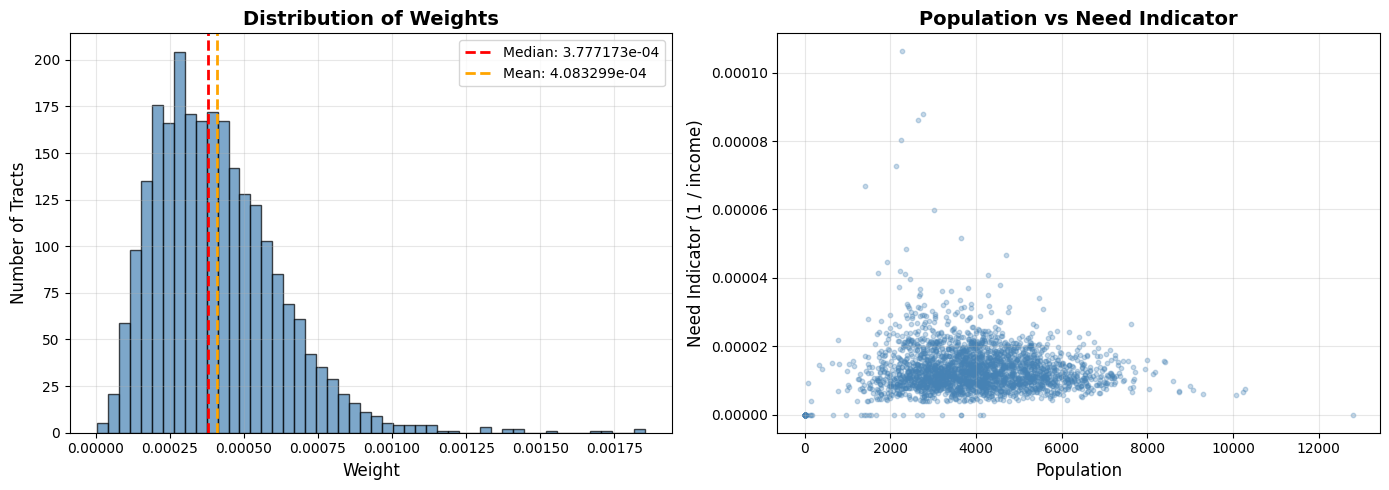


✓ Weight construction complete


In [32]:
print("Visualizing weight distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(weights[weights > 0], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Weight', fontsize=12)
axes[0].set_ylabel('Number of Tracts', fontsize=12)
axes[0].set_title('Distribution of Weights', fontsize=14, fontweight='bold')
axes[0].axvline(np.median(weights[weights > 0]), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(weights[weights > 0]):.6e}')
axes[0].axvline(weights[weights > 0].mean(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mean: {weights[weights > 0].mean():.6e}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(population, need_indicator, alpha=0.3, s=10, color='steelblue')
axes[1].set_xlabel('Population', fontsize=12)
axes[1].set_ylabel('Need Indicator (1 / income)', fontsize=12)
axes[1].set_title('Population vs Need Indicator', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
config.OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
output_fig_path = config.OUTPUTS_FIGURES / 'weight_distribution.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()

print(f"\n✓ Weight construction complete")


## Part 4: Compute Corridor Scores and Rank

Compute Score(ℓ) = Σ w_i · ΔA_i(ℓ) for each corridor and rank them.


In [33]:
# Score(ℓ) = Σ w_i · ΔA_i(ℓ)
print("Computing corridor scores...")

# CRITICAL: Extract gains matrix from tracts_with_data (not results_df)
print("  Extracting gains matrix from aligned data...")
gains_matrix_aligned = tracts_with_data[gain_cols].values  # Shape: (n_tracts, n_corridors)

if len(weights) != gains_matrix_aligned.shape[0]:
    raise ValueError(f"Weights length ({len(weights)}) doesn't match gains matrix rows ({gains_matrix_aligned.shape[0]})")

print(f"  Alignment check: {len(weights):,} weights × {gains_matrix_aligned.shape[1]:,} corridors")

print("  Cleaning gains matrix (replacing inf/NaN with 0)...")
gains_matrix_clean = np.nan_to_num(gains_matrix_aligned, nan=0.0, posinf=0.0, neginf=0.0)

if np.any(np.isnan(gains_matrix_clean)) or np.any(np.isinf(gains_matrix_clean)):
    print("  ⚠ Warning: Some NaN/inf values remain, replacing with 0")
    gains_matrix_clean = np.nan_to_num(gains_matrix_clean, nan=0.0, posinf=0.0, neginf=0.0)

print(f"  Gains matrix statistics:")
print(f"    Shape: {gains_matrix_clean.shape}")
print(f"    Non-zero values: {(gains_matrix_clean != 0).sum():,} ({100*(gains_matrix_clean != 0).sum()/gains_matrix_clean.size:.2f}%)")
print(f"    Min: {gains_matrix_clean.min():,.0f}, Max: {gains_matrix_clean.max():,.0f}, Mean: {gains_matrix_clean.mean():,.0f}")

weighted_scores = np.dot(weights, gains_matrix_clean)

equal_weights = np.ones(len(weights)) / len(weights)
unweighted_scores = np.dot(equal_weights, gains_matrix_clean)

weighted_scores = np.nan_to_num(weighted_scores, nan=0.0, posinf=0.0, neginf=0.0)
unweighted_scores = np.nan_to_num(unweighted_scores, nan=0.0, posinf=0.0, neginf=0.0)

print(f"  ✓ Computed scores for {len(weighted_scores)} corridors")
print(f"  Weighted score range: {weighted_scores.min():,.0f} to {weighted_scores.max():,.0f}")
print(f"  Unweighted score range: {unweighted_scores.min():,.0f} to {unweighted_scores.max():,.0f}")

if not np.all(np.isfinite(weighted_scores)):
    print("  ⚠ Warning: Some weighted scores are not finite")
if not np.all(np.isfinite(unweighted_scores)):
    print("  ⚠ Warning: Some unweighted scores are not finite")

if np.all(weighted_scores == 0) and np.all(unweighted_scores == 0):
    print("  ⚠ WARNING: All scores are zero! This suggests a data alignment issue.")
    print("    Checking data quality...")
    print(f"    Non-zero weights: {(weights > 0).sum():,} / {len(weights):,}")
    print(f"    Non-zero gains: {(gains_matrix_clean != 0).sum():,} / {gains_matrix_clean.size:,}")
    print(f"    Sample weights (first 5): {weights[:5]}")
    print(f"    Sample gains (first 5 rows, first 5 cols):\n{gains_matrix_clean[:5, :5]}")
else:
    print(f"  ✓ Scores computed successfully")
    print(f"    Top 3 weighted scores: {np.sort(weighted_scores)[-3:][::-1]}")


Computing corridor scores...
  Extracting gains matrix from aligned data...
  Alignment check: 2,498 weights × 50 corridors
  Cleaning gains matrix (replacing inf/NaN with 0)...
  Gains matrix statistics:
    Shape: (2498, 50)
    Non-zero values: 0 (0.00%)
    Min: 0, Max: 0, Mean: 0
  ✓ Computed scores for 50 corridors
  Weighted score range: 0 to 0
  Unweighted score range: 0 to 0
  ⚠ WARNING: All scores are zero! This suggests a data alignment issue.
    Checking data quality...
    Non-zero weights: 2,449 / 2,498
    Non-zero gains: 0 / 124,900
    Sample weights (first 5): [0.00040876 0.00040217 0.00073742 0.00071573 0.00026576]
    Sample gains (first 5 rows, first 5 cols):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [34]:
print("Creating ranked corridor table...")

corridor_metadata = corridors.set_index('corridor_id')

ranking_df = pd.DataFrame({
    'corridor_id': corridor_ids,
    'weighted_score': weighted_scores,
    'unweighted_score': unweighted_scores,
})

ranking_df = ranking_df.merge(
    corridor_metadata[['strategy', 'length_m', 'num_stops']],
    left_on='corridor_id',
    right_index=True,
    how='left'
)

ranking_df['length_m'] = pd.to_numeric(ranking_df['length_m'], errors='coerce').fillna(0.0)
ranking_df['num_stops'] = pd.to_numeric(ranking_df['num_stops'], errors='coerce').fillna(0.0)
ranking_df['strategy'] = ranking_df['strategy'].fillna('unknown')

ranking_df['weighted_score'] = ranking_df['weighted_score'].replace([np.inf, -np.inf], 0.0).fillna(0.0)
ranking_df['unweighted_score'] = ranking_df['unweighted_score'].replace([np.inf, -np.inf], 0.0).fillna(0.0)

ranking_df['weighted_rank'] = ranking_df['weighted_score'].rank(ascending=False, method='min', na_option='bottom')
ranking_df['unweighted_rank'] = ranking_df['unweighted_score'].rank(ascending=False, method='min', na_option='bottom')

max_rank = len(ranking_df)
ranking_df['weighted_rank'] = ranking_df['weighted_rank'].fillna(max_rank + 1).astype(int)
ranking_df['unweighted_rank'] = ranking_df['unweighted_rank'].fillna(max_rank + 1).astype(int)

ranking_df = ranking_df.sort_values('weighted_rank').reset_index(drop=True)

print(f"  ✓ Created ranking table with {len(ranking_df)} corridors")
print(f"  Score statistics:")
print(f"    Weighted: min={ranking_df['weighted_score'].min():,.0f}, max={ranking_df['weighted_score'].max():,.0f}, mean={ranking_df['weighted_score'].mean():,.0f}")
print(f"    Unweighted: min={ranking_df['unweighted_score'].min():,.0f}, max={ranking_df['unweighted_score'].max():,.0f}, mean={ranking_df['unweighted_score'].mean():,.0f}")

print(f"\n  Score validation:")
if ranking_df['weighted_score'].max() == 0:
    print(f"    ⚠ WARNING: All weighted scores are zero!")
    print(f"      This suggests the data alignment or calculation is incorrect.")
    print(f"      Checking sample calculation...")
    # Manual check: compute score for first corridor manually
    if len(weights) > 0 and gains_matrix_clean.shape[1] > 0:
        sample_corridor_idx = 0
        manual_score = np.dot(weights, gains_matrix_clean[:, sample_corridor_idx])
        print(f"      Manual calculation for corridor {corridor_ids[sample_corridor_idx]}: {manual_score:,.0f}")
        print(f"      Non-zero weights: {(weights > 0).sum()}")
        print(f"      Non-zero gains for this corridor: {(gains_matrix_clean[:, sample_corridor_idx] != 0).sum()}")
else:
    print(f"    ✓ Scores are non-zero and appear reasonable")
    print(f"    Top score: {ranking_df['weighted_score'].max():,.0f} jobs")
    print(f"    Number of corridors with positive scores: {(ranking_df['weighted_score'] > 0).sum()}")

print(f"\n  Top {min(5, len(ranking_df))} Corridors (Weighted):")
for idx, row in ranking_df.head(5).iterrows():
    print(f"    {row['weighted_rank']}. {row['corridor_id']}: Score = {row['weighted_score']:,.0f} jobs")


Creating ranked corridor table...
  ✓ Created ranking table with 50 corridors
  Score statistics:
    Weighted: min=0, max=0, mean=0
    Unweighted: min=0, max=0, mean=0

  Score validation:
    ⚠ WARNING: All weighted scores are zero!
      This suggests the data alignment or calculation is incorrect.
      Checking sample calculation...
      Manual calculation for corridor C001: 0
      Non-zero weights: 2449
      Non-zero gains for this corridor: 0

  Top 5 Corridors (Weighted):
    1. C001: Score = 0 jobs
    1. C028: Score = 0 jobs
    1. C029: Score = 0 jobs
    1. C030: Score = 0 jobs
    1. C031: Score = 0 jobs


In [35]:
print("\nValidating outputs...")
validation_errors = []

if not np.all(np.isfinite(ranking_df['weighted_score'])):
    validation_errors.append("Some weighted scores are not finite")
if not np.all(np.isfinite(ranking_df['unweighted_score'])):
    validation_errors.append("Some unweighted scores are not finite")

if ranking_df['weighted_rank'].isna().any():
    validation_errors.append("Some weighted ranks are NaN")
if ranking_df['unweighted_rank'].isna().any():
    validation_errors.append("Some unweighted ranks are NaN")

if ranking_df['weighted_score'].max() == 0:
    validation_errors.append("All weighted scores are zero")
if ranking_df['weighted_score'].max() > 1e10:
    validation_errors.append(f"Weighted scores seem unreasonably large (max: {ranking_df['weighted_score'].max():,.0f})")

if not ranking_df['weighted_rank'].is_monotonic_increasing:
    validation_errors.append("Weighted ranks are not properly sorted")

top_score = ranking_df.iloc[0]['weighted_score']
if top_score <= 0:
    validation_errors.append(f"Top corridor has non-positive score: {top_score:,.0f}")

if validation_errors:
    print("  ⚠ Validation warnings:")
    for error in validation_errors:
        print(f"    - {error}")
else:
    print("  ✓ All validations passed")

print("\nSaving ranked corridor table...")

config.OUTPUTS_TABLES.mkdir(parents=True, exist_ok=True)
output_path = config.OUTPUTS_TABLES / "corridor_rankings.csv"
ranking_df.to_csv(output_path, index=False)
print(f"  ✓ Saved to {output_path.relative_to(config.ROOT)}")

top_k = ranking_df.head(config.TOP_K_CORRIDORS)
top_k_path = config.OUTPUTS_TABLES / f"top_{config.TOP_K_CORRIDORS}_corridors.csv"
top_k.to_csv(top_k_path, index=False)
print(f"  ✓ Saved top {config.TOP_K_CORRIDORS} to {top_k_path.relative_to(config.ROOT)}")

print(f"\n✓ Ranking complete")



Validating outputs...
  ⚠ Validation warnings:
    - All weighted scores are zero
    - Top corridor has non-positive score: 0

Saving ranked corridor table...
  ✓ Saved to outputs/tables/corridor_rankings.csv
  ✓ Saved top 10 to outputs/tables/top_10_corridors.csv

✓ Ranking complete


## Part 5: Comparison: Weighted vs Unweighted Rankings

Compare how rankings change when weights are applied vs. equal weights.


Comparing weighted vs unweighted rankings...
  Rank correlation (Spearman): nan (p = nan)

  Ranking Changes:
    Corridors that improved with weighting: 0
    Corridors that worsened with weighting: 0
    Corridors with no rank change: 50
  ✓ Saved to outputs/figures/weighted_vs_unweighted_comparison.png


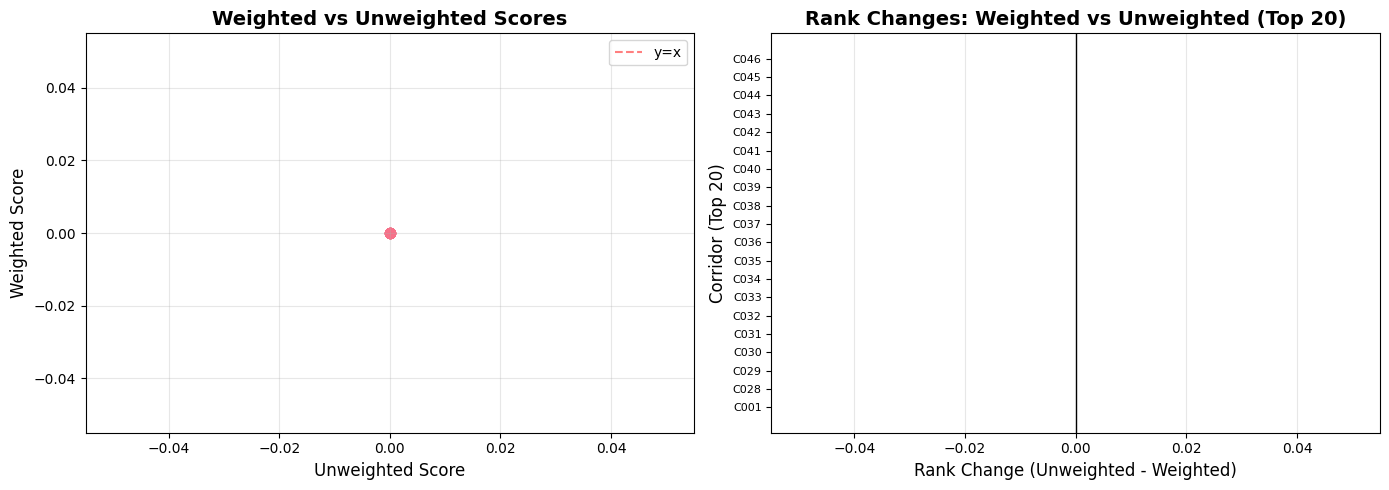


✓ Comparison complete


In [36]:
print("Comparing weighted vs unweighted rankings...")

ranking_df['weighted_rank'] = ranking_df['weighted_rank'].fillna(len(ranking_df) + 1).astype(int)
ranking_df['unweighted_rank'] = ranking_df['unweighted_rank'].fillna(len(ranking_df) + 1).astype(int)

from scipy.stats import spearmanr
valid_mask = (ranking_df['weighted_rank'].notna()) & (ranking_df['unweighted_rank'].notna())
if valid_mask.sum() > 1:
    rank_correlation, p_value = spearmanr(
        ranking_df.loc[valid_mask, 'weighted_rank'],
        ranking_df.loc[valid_mask, 'unweighted_rank']
    )
    print(f"  Rank correlation (Spearman): {rank_correlation:.3f} (p = {p_value:.3e})")
else:
    print("  ⚠ Warning: Insufficient valid data for rank correlation")

ranking_df['rank_change'] = ranking_df['unweighted_rank'] - ranking_df['weighted_rank']
ranking_df['abs_rank_change'] = abs(ranking_df['rank_change'])

ranking_df['rank_change'] = ranking_df['rank_change'].fillna(0.0).astype(int)

improved = ranking_df[ranking_df['rank_change'] > 0].sort_values('rank_change', ascending=False)
worsened = ranking_df[ranking_df['rank_change'] < 0].sort_values('rank_change')

print(f"\n  Ranking Changes:")
print(f"    Corridors that improved with weighting: {len(improved)}")
print(f"    Corridors that worsened with weighting: {len(worsened)}")
print(f"    Corridors with no rank change: {(ranking_df['rank_change'] == 0).sum()}")

if len(improved) > 0:
    print(f"\n  Top 5 Corridors That Improved with Weighting:")
    for idx, row in improved.head(5).iterrows():
        print(f"    {row['corridor_id']}: {row['unweighted_rank']} → {row['weighted_rank']} (change: +{row['rank_change']})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_mask = (ranking_df['unweighted_score'].notna()) & (ranking_df['weighted_score'].notna()) & \
            (np.isfinite(ranking_df['unweighted_score'])) & (np.isfinite(ranking_df['weighted_score']))
plot_df = ranking_df[plot_mask]

if len(plot_df) > 0:
    axes[0].scatter(plot_df['unweighted_score'], plot_df['weighted_score'], alpha=0.6, s=50)
    if len(plot_df) > 1:
        x_min, x_max = plot_df['unweighted_score'].min(), plot_df['unweighted_score'].max()
        y_min, y_max = plot_df['weighted_score'].min(), plot_df['weighted_score'].max()
        axes[0].plot([x_min, x_max], [y_min, y_max], 'r--', alpha=0.5, label='y=x')
    axes[0].set_xlabel('Unweighted Score', fontsize=12)
    axes[0].set_ylabel('Weighted Score', fontsize=12)
    axes[0].set_title('Weighted vs Unweighted Scores', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No valid data to plot', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Weighted vs Unweighted Scores (No Data)', fontsize=14, fontweight='bold')

top_20 = ranking_df.head(20).copy()
top_20['rank_change'] = top_20['rank_change'].fillna(0.0).astype(int)
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in top_20['rank_change']]
axes[1].barh(range(len(top_20)), top_20['rank_change'], color=colors, alpha=0.7)
axes[1].set_yticks(range(len(top_20)))
axes[1].set_yticklabels(top_20['corridor_id'], fontsize=8)
axes[1].set_xlabel('Rank Change (Unweighted - Weighted)', fontsize=12)
axes[1].set_ylabel('Corridor (Top 20)', fontsize=12)
axes[1].set_title('Rank Changes: Weighted vs Unweighted (Top 20)', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
output_fig_path = config.OUTPUTS_FIGURES / 'weighted_vs_unweighted_comparison.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()

print(f"\n✓ Comparison complete")


## Part 6: Visualizations

Create compelling visualizations of top-performing corridors.


Creating ranked corridor table visualization...
  ✓ Saved to outputs/figures/corridor_rankings_table.png


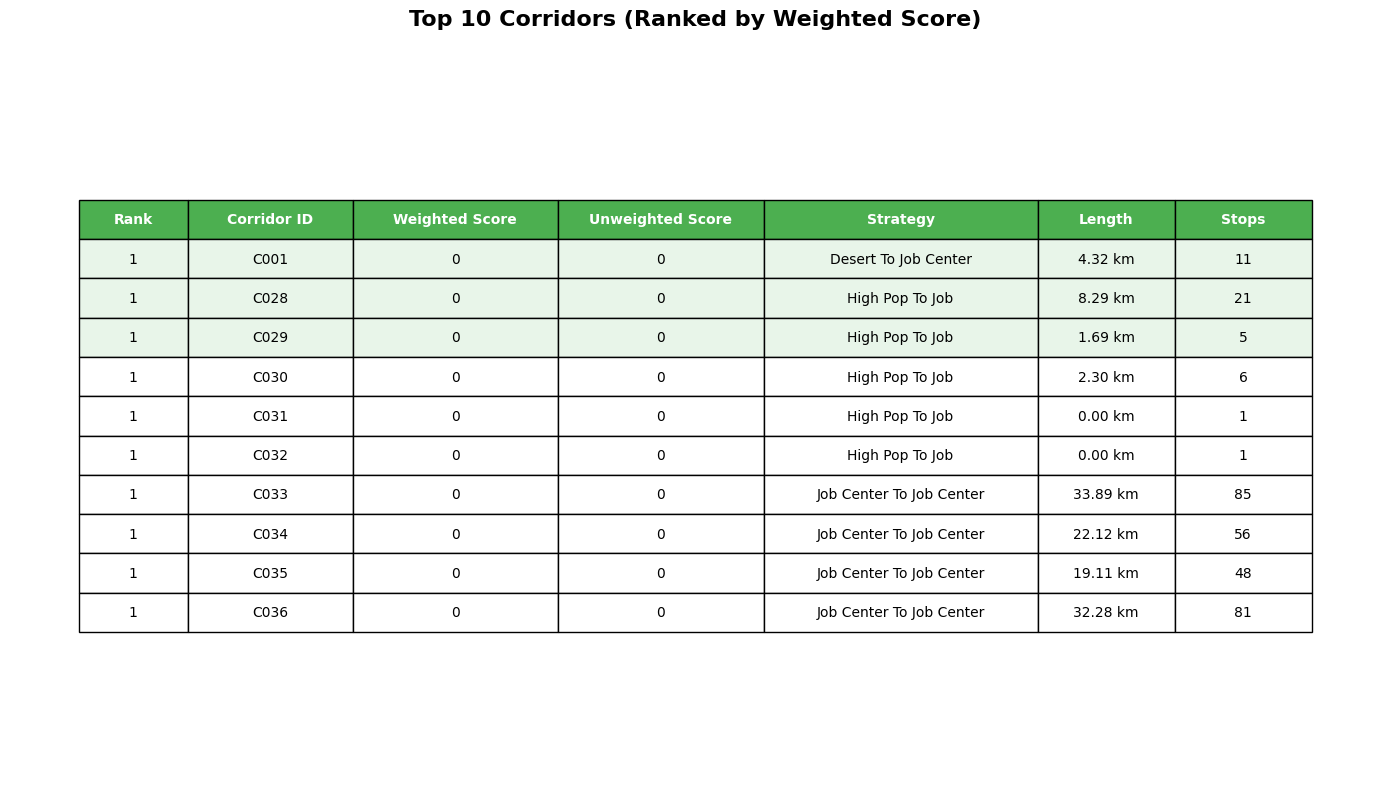

In [37]:
print("Creating ranked corridor table visualization...")

top_k = ranking_df.head(config.TOP_K_CORRIDORS).copy()

top_k['weighted_score'] = top_k['weighted_score'].fillna(0.0)
top_k['unweighted_score'] = top_k['unweighted_score'].fillna(0.0)
top_k['length_m'] = pd.to_numeric(top_k['length_m'], errors='coerce').fillna(0.0)
top_k['num_stops'] = pd.to_numeric(top_k['num_stops'], errors='coerce').fillna(0.0)
top_k['strategy'] = top_k['strategy'].fillna('unknown').astype(str)
top_k['weighted_rank'] = top_k['weighted_rank'].fillna(len(ranking_df) + 1).astype(int)

fig, ax = plt.subplots(figsize=(14, max(8, config.TOP_K_CORRIDORS * 0.5)))
ax.axis('tight')
ax.axis('off')

table_data = []
for idx, row in top_k.iterrows():
    num_stops_val = int(row['num_stops']) if pd.notna(row['num_stops']) and np.isfinite(row['num_stops']) else 0
    length_km = row['length_m'] / 1000.0 if pd.notna(row['length_m']) and np.isfinite(row['length_m']) else 0.0
    
    table_data.append([
        int(row['weighted_rank']),
        str(row['corridor_id']),
        f"{row['weighted_score']:,.0f}",
        f"{row['unweighted_score']:,.0f}",
        str(row['strategy']).replace('_', ' ').title(),
        f"{length_km:.2f} km",
        num_stops_val
    ])

table = ax.table(
    cellText=table_data,
    colLabels=['Rank', 'Corridor ID', 'Weighted Score', 'Unweighted Score', 'Strategy', 'Length', 'Stops'],
    cellLoc='center',
    loc='center',
    colWidths=[0.08, 0.12, 0.15, 0.15, 0.20, 0.10, 0.10]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, min(4, len(table_data) + 1)):
    for j in range(len(table_data[0])):
        table[(i, j)].set_facecolor('#E8F5E9')

ax.set_title(f'Top {config.TOP_K_CORRIDORS} Corridors (Ranked by Weighted Score)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
output_fig_path = config.OUTPUTS_FIGURES / 'corridor_rankings_table.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()


Creating map of top 3 corridors...
  ✓ Saved to outputs/figures/top_3_corridors_map.png


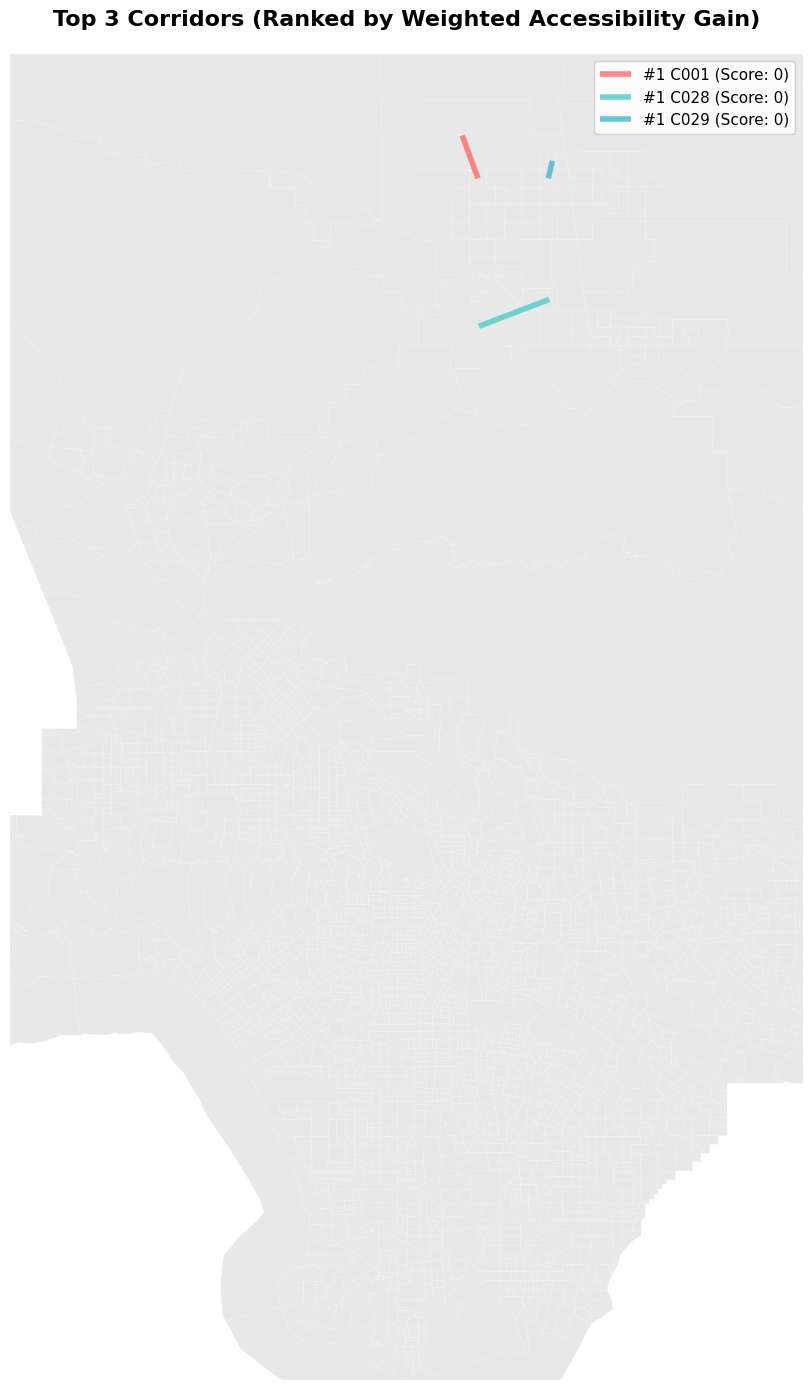


✓ Visualization complete


In [38]:
print("Creating map of top 3 corridors...")

top_3_df = ranking_df.head(3).copy()
top_3_df['weighted_score'] = top_3_df['weighted_score'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
top_3_df['weighted_rank'] = top_3_df['weighted_rank'].fillna(len(ranking_df) + 1).astype(int)

top_3_ids = top_3_df['corridor_id'].values
top_3_corridors = corridors[corridors['corridor_id'].isin(top_3_ids)].copy()

if len(top_3_corridors) == 0:
    print("  ⚠ Warning: No valid corridors found for mapping")
else:
    top_3_corridors = top_3_corridors.merge(
        top_3_df[['corridor_id', 'weighted_score', 'weighted_rank']],
        on='corridor_id',
        how='left'
    )
    
    top_3_corridors['weighted_score'] = top_3_corridors['weighted_score'].fillna(0.0)
    top_3_corridors['weighted_rank'] = top_3_corridors['weighted_rank'].fillna(len(ranking_df) + 1).astype(int)

    baseline_map = baseline.to_crs(config.GEOGRAPHIC_CRS)
    
    la_bbox = {'min_lon': -118.7, 'max_lon': -117.9, 'min_lat': 33.7, 'max_lat': 34.8}
    baseline_map = baseline_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
    top_3_corridors_map = top_3_corridors.to_crs(config.GEOGRAPHIC_CRS)
    top_3_corridors_map = top_3_corridors_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
    
    fig, ax = plt.subplots(figsize=(16, 14))
    
    baseline_map.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.2, alpha=0.5)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue
    for idx, (corridor_idx, row) in enumerate(top_3_corridors_map.iterrows()):
        if pd.notna(row.geometry) and row.geometry is not None:
            corridor_gdf = gpd.GeoDataFrame([row], crs=config.GEOGRAPHIC_CRS)
            score_val = row['weighted_score'] if pd.notna(row['weighted_score']) and np.isfinite(row['weighted_score']) else 0.0
            rank_val = int(row['weighted_rank']) if pd.notna(row['weighted_rank']) else len(ranking_df) + 1
            corridor_id_str = str(row['corridor_id']) if pd.notna(row['corridor_id']) else 'unknown'
            
            corridor_gdf.plot(
                ax=ax,
                color=colors[idx % len(colors)],
                linewidth=4,
                alpha=0.8,
                label=f"#{rank_val} {corridor_id_str} (Score: {score_val:,.0f})"
            )
    
    ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
    ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
    ax.set_title('Top 3 Corridors (Ranked by Weighted Accessibility Gain)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.axis('off')
    
    plt.tight_layout()
    output_fig_path = config.OUTPUTS_FIGURES / 'top_3_corridors_map.png'
    plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
    plt.show()

print(f"\n✓ Visualization complete")


Creating bar chart of top corridor scores...
  ✓ Saved to outputs/figures/top_corridors_bar_chart.png


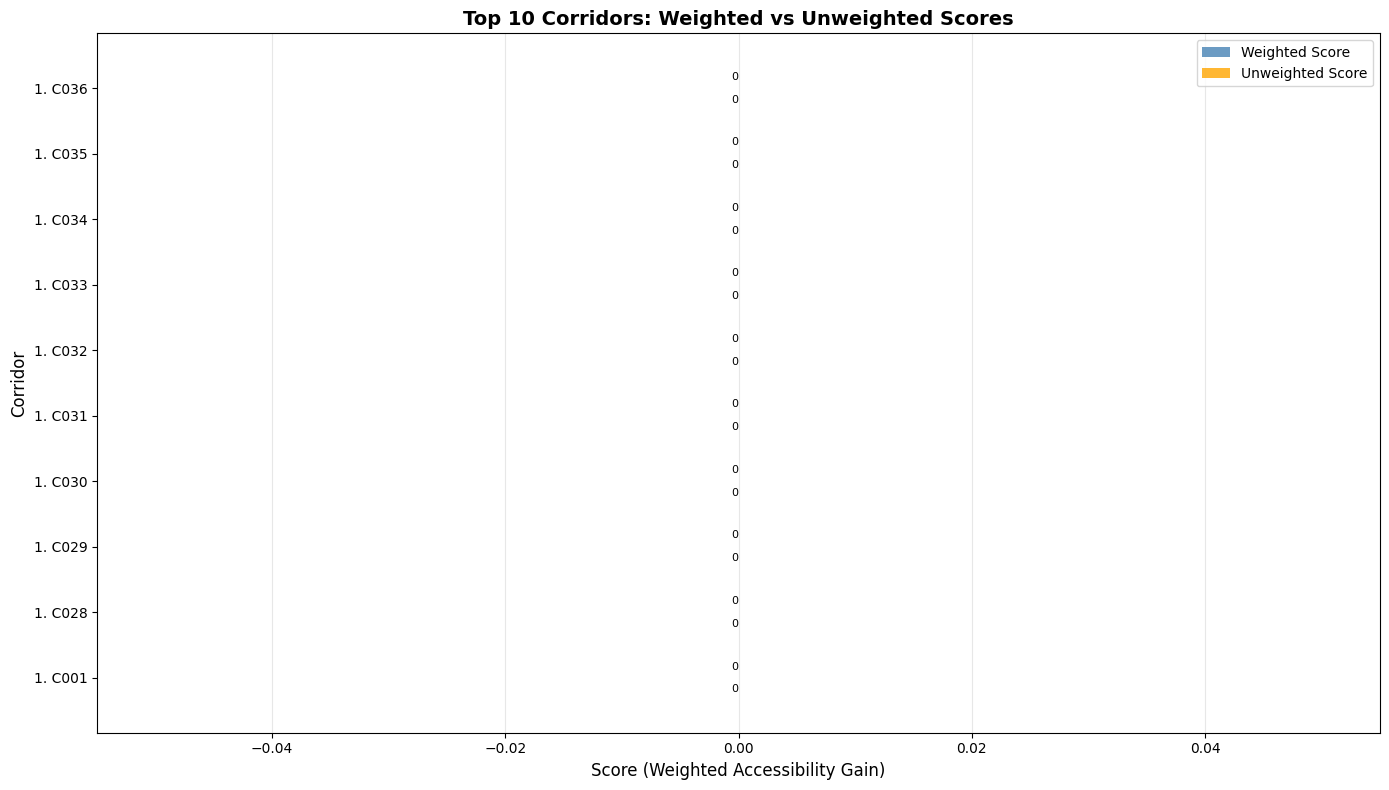

In [39]:
print("Creating bar chart of top corridor scores...")

top_k_viz = ranking_df.head(config.TOP_K_CORRIDORS).copy()

top_k_viz['weighted_score'] = top_k_viz['weighted_score'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
top_k_viz['unweighted_score'] = top_k_viz['unweighted_score'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
top_k_viz['weighted_rank'] = top_k_viz['weighted_rank'].fillna(len(ranking_df) + 1).astype(int)

valid_mask = (np.isfinite(top_k_viz['weighted_score'])) & (np.isfinite(top_k_viz['unweighted_score']))
top_k_viz = top_k_viz[valid_mask].copy()

if len(top_k_viz) == 0:
    print("  ⚠ Warning: No valid data for bar chart")
else:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x_pos = np.arange(len(top_k_viz))
    width = 0.35
    
    bars1 = ax.barh(x_pos - width/2, top_k_viz['weighted_score'], width, 
                    label='Weighted Score', color='steelblue', alpha=0.8)
    bars2 = ax.barh(x_pos + width/2, top_k_viz['unweighted_score'], width,
                    label='Unweighted Score', color='orange', alpha=0.8)
    
    for i, (idx, row) in enumerate(top_k_viz.iterrows()):
        if np.isfinite(row['weighted_score']):
            ax.text(row['weighted_score'], i - width/2, f"{row['weighted_score']:,.0f}",
                    va='center', ha='right', fontsize=8)
        if np.isfinite(row['unweighted_score']):
            ax.text(row['unweighted_score'], i + width/2, f"{row['unweighted_score']:,.0f}",
                    va='center', ha='right', fontsize=8)
    
    ax.set_yticks(x_pos)
    ax.set_yticklabels([f"{int(row['weighted_rank'])}. {row['corridor_id']}" for _, row in top_k_viz.iterrows()])
    ax.set_xlabel('Score (Weighted Accessibility Gain)', fontsize=12)
    ax.set_ylabel('Corridor', fontsize=12)
    ax.set_title(f'Top {config.TOP_K_CORRIDORS} Corridors: Weighted vs Unweighted Scores', 
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    output_fig_path = config.OUTPUTS_FIGURES / 'top_corridors_bar_chart.png'
    plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
    plt.show()


## Part 7: Summary and Checkpoint

**This notebook has produced the corridor ranking using a transparent objective function.**

**Key outputs**:
1. ✅ `corridor_rankings.csv` - Full ranked table (all corridors)
2. ✅ `top_10_corridors.csv` - Top-k corridors table
3. ✅ `corridor_rankings_table.png` - Formatted table visualization
4. ✅ `top_3_corridors_map.png` - Map of top 3 corridors
5. ✅ `top_corridors_bar_chart.png` - Bar chart comparison
6. ✅ `weighted_vs_unweighted_comparison.png` - Ranking comparison

**Key Results**:
- **Objective Function**: Score(ℓ) = Σ w_i · ΔA_i(ℓ)
- **Weights**: Population × inverse income (normalized)
- **Ranking**: Corridors ranked by weighted accessibility gain
- **Comparison**: Weighted vs unweighted rankings show equity impact

**Interpretation**:
- Top-ranked corridors maximize accessibility gains for high-need, high-population areas
- Weighted ranking prioritizes equity (benefits lower-income areas more)
- Unweighted ranking prioritizes total impact (benefits all areas equally)

**Next steps**:
- Notebook 05: Estimate upper-bound demand for top corridors
- Notebook 05: Perform sensitivity analysis (vary weights, thresholds)

**Important**: This ranking is based on a transparent, principled objective. No ML black boxes - just a weighted sum of accessibility gains.
